# OLS and the Inferential Toolkit

**Chapter 11 | Section 11.1**

**Docker image**: `ml4t`

This notebook shows what classical inference looks like before we leave it behind.
Using the same ETF features and labels as the rest of Chapter 11, we fit a
statsmodels OLS model and walk through the full inferential toolkit: coefficient
significance, Gauss-Markov diagnostics, and robust standard errors.

**Learning objectives**

- Interpret a statsmodels OLS summary: coefficients, standard errors, t-statistics, p-values
- Test the spherical-errors condition on a panel: heteroscedasticity and residual autocorrelation
- Identify multicollinearity via Variance Inflation Factors (VIF)
- Separate what robust standard errors repair from what they cannot
- Understand why inference diagnostics do not answer the prediction question

**Book reference**

Section 11.1 ("From Inference to Prediction"). The next notebook,
`02_regularization_paths`, transitions to the prediction-oriented framework.

**Prerequisites**

- Familiarity with linear regression and the Gauss-Markov assumptions.
- Conceptual exposure to heteroscedasticity, autocorrelation, and VIF.
- ETF case-study features at `case_studies/etfs/features/financial.parquet`
  (Ch8 output) and labels at `case_studies/etfs/labels/fwd_ret_21d.parquet`
  (Ch7 output).

## Setup

In [1]:
"""OLS and the Inferential Toolkit — classical inference diagnostics before the prediction pivot."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import statsmodels.api as sm
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera

from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
MAX_SYMBOLS = 0
MAX_TRAIN_ROWS = 0
VIF_MAX_ROWS = 0

In [3]:
set_global_seeds(SEED)

## Load Features and Labels

We use the same ETF case study data as the rest of Chapter 11: financial
features from Ch8 and 21-day forward return labels from Ch7.

In [4]:
CASE_DIR = get_case_study_dir("etfs")

FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"
LABELS_PATH = CASE_DIR / "labels" / "fwd_ret_21d.parquet"

assert FEATURES_PATH.exists(), f"Features not found: {FEATURES_PATH}\nRun Ch8 ETF features first."
assert LABELS_PATH.exists(), f"Labels not found: {LABELS_PATH}\nRun Ch7 ETF labels first."

features_df = pl.read_parquet(FEATURES_PATH).with_columns(pl.col("timestamp").cast(pl.Date))
labels_df = pl.read_parquet(LABELS_PATH).with_columns(pl.col("timestamp").cast(pl.Date))

In [5]:
TARGET_COL = "fwd_ret_21d"
ASSET_COL = "symbol"

df = features_df.join(labels_df, on=["timestamp", ASSET_COL], how="inner")

META_COLS = {"timestamp", ASSET_COL, TARGET_COL}
FEATURE_COLS = sorted(c for c in df.columns if c not in META_COLS)

# Drop features that are entirely null (can happen with reduced test universes)
all_null = [c for c in FEATURE_COLS if df[c].null_count() == df.height]
if all_null:
    print(f"Dropping {len(all_null)} all-null features: {all_null}")
    df = df.drop(all_null)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in all_null]

# Replace inf/NaN with null, then drop all nulls
df = df.with_columns(
    [
        pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
        .then(None)
        .otherwise(pl.col(c))
        .alias(c)
        for c in FEATURE_COLS
    ]
)
df = df.drop_nulls(subset=FEATURE_COLS + [TARGET_COL]).sort(["timestamp", ASSET_COL])

Ch8 builds the `skip_recent` and `mom_accel` features as differences of return
horizons, so `skip_recent_12_1` is `ret_252d - ret_21d`. Keeping both the raw
returns and the derived differences makes the design matrix singular, which is
a violation of the no-perfect-multicollinearity assumption severe enough that
the robust covariance estimators below cannot be computed at all. We drop the
five composites.

In [6]:
REDUNDANT = {
    "mom_accel_short",
    "mom_accel_medium",
    "mom_accel_long",
    "skip_recent_6_1",
    "skip_recent_12_1",
}
n_redundant = len(REDUNDANT & set(FEATURE_COLS))
FEATURE_COLS = [c for c in FEATURE_COLS if c not in REDUNDANT]
if n_redundant:
    print(f"Dropped {n_redundant} linearly dependent features (return-difference composites)")

if MAX_SYMBOLS > 0:
    assets = df[ASSET_COL].unique().sort().head(MAX_SYMBOLS).to_list()
    df = df.filter(pl.col(ASSET_COL).is_in(assets))

print(f"Shape: {df.height:,} rows x {len(FEATURE_COLS)} features")
print(f"Assets: {df[ASSET_COL].n_unique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Dropped 5 linearly dependent features (return-difference composites)
Shape: 393,985 rows x 52 features
Assets: 99
Date range: 2007-01-04 to 2025-12-01


## Select a Single Training Fold

Inference is an in-sample exercise — we fit one model on one training window
and examine its properties. We use the first walk-forward fold and hold back
the validation set for a prediction comparison at the end.

In [7]:
splits = generate_cv_splits(df, case_study_id="etfs", label_buffer="21D", date_col="timestamp")

s = splits[0]
tr_start = np.datetime64(s["train_start"])
tr_end = np.datetime64(s["train_end"])
val_start = np.datetime64(s["val_start"])
val_end = np.datetime64(s["val_end"])

dates_np = df["timestamp"].to_numpy()
train_mask = (dates_np >= tr_start) & (dates_np <= tr_end)
val_mask = (dates_np >= val_start) & (dates_np <= val_end)

train_df = df.filter(train_mask)
X_train_raw = train_df.select(FEATURE_COLS).to_numpy()
y_train = train_df[TARGET_COL].to_numpy()
train_meta = train_df.select(["timestamp", ASSET_COL])
X_val_raw = df.filter(val_mask).select(FEATURE_COLS).to_numpy()
y_val = df.filter(val_mask)[TARGET_COL].to_numpy()

if MAX_TRAIN_ROWS > 0 and len(y_train) > MAX_TRAIN_ROWS:
    # Whole symbols, never individual rows: the lag-1 and lag-21 diagnostics below
    # read off each symbol's own series, and a random draw of rows would leave gaps.
    symbols_arr = train_meta[ASSET_COL].to_numpy()
    unique_symbols = np.unique(symbols_arr)
    rows_per_symbol = max(1, len(y_train) // len(unique_symbols))
    n_keep = max(1, min(len(unique_symbols), MAX_TRAIN_ROWS // rows_per_symbol))
    keep = np.random.default_rng(42).choice(unique_symbols, size=n_keep, replace=False)
    idx = np.flatnonzero(np.isin(symbols_arr, keep))
    X_train_raw = X_train_raw[idx]
    y_train = y_train[idx]
    train_meta = train_meta[idx]
    print(f"Subsampled to {n_keep} whole symbols ({len(idx):,} rows) for faster diagnostics")

# Standardize features (fitted on training data only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)

# Keep feature names for statsmodels output (x1/x2/... is hard to interpret).
X_train_df = pd.DataFrame(X_train, columns=FEATURE_COLS)
X_val_df = pd.DataFrame(X_val, columns=FEATURE_COLS)
y_train_s = pd.Series(y_train, name=TARGET_COL)

print(f"Training: {len(y_train):,} observations ({s['train_start']} to {s['train_end']})")
print(f"Validation: {len(y_val):,} observations ({s['val_start']} to {s['val_end']})")

Training: 226,959 observations (2012-12-31 00:00:00 to 2022-11-28 00:00:00)
Validation: 22,174 observations (2022-12-29 00:00:00 to 2023-11-29 00:00:00)


## Section 1: Statsmodels OLS Summary

Statsmodels provides the full inferential output that scikit-learn omits:
coefficient standard errors, t-statistics, p-values, and model-level diagnostics.

In [8]:
X_train_c = sm.add_constant(X_train_df, has_constant="add")
ols_model = sm.OLS(y_train_s, X_train_c).fit()

In [9]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            fwd_ret_21d   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     407.4
Date:                Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:40:52   Log-Likelihood:             3.3690e+05
No. Observations:              226959   AIC:                        -6.737e+05
Df Residuals:                  226906   BIC:                        -6.731e+05
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0058      0

**Reading the summary**: The coefficients table shows many features with small
p-values in the `P>|t|` column, which might seem to indicate "significant" predictors.
But the overall $R^2$ is very low — typical for cross-sectional return prediction.
A large sample (hundreds of thousands of observations) makes even tiny effects
"significant" in the statistical sense, while the economic magnitude may be
negligible. Note that even after removing the five exact linear combinations,
the remaining features are still pervasively correlated (as VIF will confirm),
so coefficient estimates are unstable across samples.

Crucially, these standard errors assume **spherical errors**: constant variance,
uncorrelated across observations. We now test that condition, and the
no-perfect-multicollinearity condition alongside it.

## Section 2: Gauss-Markov Diagnostic Battery

Section 11.1 states the four Gauss-Markov assumptions: linearity in the
parameters, strict exogeneity, no perfect multicollinearity, and spherical
errors. When all four hold, OLS is the Best Linear Unbiased Estimator (BLUE).

Only two of the four are testable from residuals. Spherical errors decompose
into constant variance (Breusch-Pagan, below) and no correlation across
observations (residual autocorrelation, below); multicollinearity is read off
the design matrix via VIF. Linearity and exogeneity are assumptions about the
data-generating process that residuals cannot confirm — a misspecified model
can produce well-behaved residuals.

We also test normality, which is **not** a Gauss-Markov assumption. It is
required for exact finite-sample t and F distributions, not for BLUE.

### Heteroscedasticity: Breusch-Pagan Test

Tests whether the error variance depends on the regressors. Financial returns
exhibit time-varying volatility (volatility clustering), so we expect rejection.

In [10]:
residuals = ols_model.resid
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(residuals, X_train_c)

print(f"Breusch-Pagan LM statistic: {bp_stat:.1f}")
print(f"p-value: {bp_pvalue:.2e}")
print(f"F-statistic: {bp_fstat:.1f} (p = {bp_fpvalue:.2e})")

if bp_pvalue < 0.05:
    print("\nResult: REJECT homoscedasticity.")
    print("Consequence: OLS standard errors are biased — t-stats and p-values are unreliable.")
else:
    print("\nResult: Cannot reject homoscedasticity at 5% level.")

Breusch-Pagan LM statistic: 25954.9
p-value: 0.00e+00
F-statistic: 563.5 (p = 0.00e+00)

Result: REJECT homoscedasticity.
Consequence: OLS standard errors are biased — t-stats and p-values are unreliable.


### Correlated Errors: Residual Autocorrelation Within Each Asset

This is a panel: many symbols observed on the same dates. The residual vector
is stored in date order, so its neighbouring entries are *different assets on
the same day*, not consecutive observations of one asset. A Durbin-Watson or
Breusch-Godfrey statistic computed on that vector measures cross-sectional
dependence and reports it under the name of serial correlation.

To test serial correlation we regroup the residuals into one time-ordered
series per symbol and measure autocorrelation within each. Two lags are
informative here. Lag 1 asks whether yesterday's error predicts today's. Lag
21 sits at the label horizon: `fwd_ret_21d` is a 21-day forward return, so
consecutive daily observations of one asset share 20 of 21 days of outcome
window. That overlap induces autocorrelation by construction out to lag 20 and
is the dominant source of the correlation we find.

In [11]:
resid_panel = train_meta.with_columns(residual=pl.Series(np.asarray(residuals))).sort(
    [ASSET_COL, "timestamp"]
)

LAGS = (1, 5, 21)
per_symbol = {lag: [] for lag in LAGS}
dw_per_symbol = []
for (_symbol,), group in resid_panel.group_by([ASSET_COL], maintain_order=True):
    r = group["residual"].to_numpy()
    if len(r) < max(LAGS) + 2:
        continue
    dw_per_symbol.append(durbin_watson(r))
    for lag in LAGS:
        per_symbol[lag].append(np.corrcoef(r[:-lag], r[lag:])[0, 1])

autocorr_df = pl.DataFrame(
    {
        "lag": list(LAGS),
        "median_autocorr": [float(np.median(per_symbol[lag])) for lag in LAGS],
        "share_positive": [float(np.mean(np.array(per_symbol[lag]) > 0)) for lag in LAGS],
    }
)

print(f"Symbols with enough history for the test: {len(dw_per_symbol)}")
print(f"Median within-symbol Durbin-Watson: {float(np.median(dw_per_symbol)):.4f}")
print("  (2.0 = no autocorrelation; <2 = positive; >2 = negative)")
autocorr_df

Symbols with enough history for the test: 99
Median within-symbol Durbin-Watson: 0.1159
  (2.0 = no autocorrelation; <2 = positive; >2 = negative)


lag,median_autocorr,share_positive
i64,f64,f64
1,0.941393,1.0
5,0.73376,1.0
21,-0.051135,0.363636


### Normality: Jarque-Bera Test

Normality of the errors is not one of the four Gauss-Markov assumptions, and
OLS remains BLUE without it. It is what makes the t and F statistics follow
exactly those distributions in a finite sample. At this sample size the
central limit theorem delivers approximate normality of the coefficient
estimates regardless, so a rejection here is the least consequential of the
diagnostics in this section.

Financial returns have fat tails and excess kurtosis, so this will almost
certainly reject.

In [12]:
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)

print(f"Jarque-Bera statistic: {jb_stat:.1f}")
print(f"p-value: {jb_pvalue:.2e}")
print(f"Skewness: {skew:.3f} (normal = 0)")
print(f"Excess kurtosis: {kurtosis:.3f} (normal = 0)")

if jb_pvalue < 0.05:
    print("\nResult: REJECT normality.")
    print("Consequence: exact finite-sample t and F distributions do not hold; at this")
    print("sample size the central limit theorem makes the normal approximation adequate.")
else:
    print("\nResult: Cannot reject normality at 5% level.")

Jarque-Bera statistic: 1123334.4
p-value: 0.00e+00
Skewness: -1.002 (normal = 0)
Excess kurtosis: 13.713 (normal = 0)

Result: REJECT normality.
Consequence: exact finite-sample t and F distributions do not hold; at this
sample size the central limit theorem makes the normal approximation adequate.


### Multicollinearity: Variance Inflation Factors

VIF measures how much each coefficient's variance is inflated by correlation
with other features. VIF > 5 is a common concern threshold; VIF > 10 indicates
severe multicollinearity. Financial features (momentum at different horizons,
volatility measures) are pervasively correlated.

In [13]:
X_vif = X_train_c
if VIF_MAX_ROWS > 0 and len(X_vif) > VIF_MAX_ROWS:
    idx = np.random.default_rng(43).choice(len(X_vif), size=VIF_MAX_ROWS, replace=False)
    X_vif = X_vif.iloc[idx]
    print(f"VIF computed on {VIF_MAX_ROWS:,} sampled rows")

x_vif_values = X_vif.to_numpy()
vif_values = [variance_inflation_factor(x_vif_values, i) for i in range(1, x_vif_values.shape[1])]
vif_df = pl.DataFrame({"feature": FEATURE_COLS, "vif": vif_values}).sort("vif", descending=True)

n_high = vif_df.filter(pl.col("vif") > 10).height
n_moderate = vif_df.filter((pl.col("vif") > 5) & (pl.col("vif") <= 10)).height

print(f"VIF > 10 (severe): {n_high} features")
print(f"VIF 5-10 (moderate): {n_moderate} features")
vif_df.head(15)

VIF > 10 (severe): 31 features
VIF 5-10 (moderate): 6 features


feature,vif
str,f64
"""rsi_14""",140.976696
"""sma_ratio_50""",112.042696
"""ema_ratio_26""",96.061861
"""rsi_7""",70.90947
"""bb_pctb_20""",66.464211
…,…
"""vol_21d""",25.176124
"""natr_14""",24.317206
"""sharpe_189d""",21.050515


High VIF confirms what Section 11.1 discusses: financial features are pervasively
correlated. Momentum at 5-day and 21-day horizons, different volatility measures,
and volume-price indicators share overlapping information. OLS distributes weight
arbitrarily among correlated features, producing unstable coefficient estimates
that flip sign across samples.

## Section 3: When Standard Errors Fail — Robust Alternatives

Robust standard errors address exactly one failure: non-spherical errors. The
point estimates are unchanged and, if linearity and exogeneity hold, they stay
consistent; only the variance estimate around them is repaired.

They do nothing for the other two assumptions. If the model omits a relevant
variable or gets the functional form wrong, exogeneity fails, the coefficients
themselves are not consistent, and a robust standard error is a more careful
statement about the wrong quantity. Section 11.1 makes this point directly:
when the model is misspecified, the unbiasedness guarantee fails and the
coefficients stop being interpretable as structural parameters. No covariance
estimator recovers it.

### Comparing Standard Error Estimates

We compare three standard error estimates:

- **OLS** (default): assumes homoscedastic, uncorrelated errors
- **HC3** (heteroscedasticity-consistent): corrects for non-constant variance
- **Clustered by date**: allows arbitrary correlation among all observations
  sharing a date — the cross-sectional dependence
- **Clustered two ways, by date and by symbol**: additionally allows arbitrary
  correlation within a symbol across time — the serial dependence

The two diagnostics above found two different violations, and the estimator has
to answer both. Clustering by date alone handles the first and assumes the
residuals of one symbol are independent across dates, which is exactly what the
lag-21 autocorrelation shows is false: the 21-day label makes consecutive
observations of a symbol share 20 of 21 days of outcome window. Two-way
clustering drops both independence assumptions and makes no assumption about
the form of either dependence, so it is the estimator this panel needs.

HAC (Newey-West) is the usual answer to autocorrelation, but it reads its lags
off the row order of a single time series. On a pooled panel stored in date
order those lags run across the cross-section, so it does not estimate what its
name promises here. It becomes the right tool once the panel is collapsed to
one observation per date, which is what the IC calculation below does.

In [14]:
ols_hc3 = sm.OLS(y_train_s, X_train_c).fit(cov_type="HC3")
date_groups = train_meta["timestamp"].to_physical().to_numpy()
symbol_groups = train_meta[ASSET_COL].cast(pl.Categorical).to_physical().to_numpy()
ols_cluster_date = sm.OLS(y_train_s, X_train_c).fit(
    cov_type="cluster", cov_kwds={"groups": date_groups}
)
ols_cluster = sm.OLS(y_train_s, X_train_c).fit(
    cov_type="cluster", cov_kwds={"groups": np.column_stack([date_groups, symbol_groups])}
)
print(f"Date clusters:   {len(np.unique(date_groups)):,}")
print(f"Symbol clusters: {len(np.unique(symbol_groups)):,}")

# Compare SEs and t-stats for features (skip constant at index 0)
se_comparison = pl.DataFrame(
    {
        "feature": FEATURE_COLS,
        "coef": ols_model.params[1:],
        "se_ols": ols_model.bse[1:],
        "se_hc3": ols_hc3.bse[1:],
        "se_date": ols_cluster_date.bse[1:],
        "se_cluster": ols_cluster.bse[1:],
        "t_ols": ols_model.tvalues[1:],
        "t_cluster": ols_cluster.tvalues[1:],
    }
).with_columns(
    se_ratio_cluster=pl.col("se_cluster") / pl.col("se_ols"),
)

Date clusters:   2,496
Symbol clusters: 99


The features whose robust standard errors differ most from their OLS ones.
Reading left to right across the SE columns shows what each dependence the
estimator admits costs in precision.

In [15]:
cluster_ranked = (
    se_comparison.sort("se_ratio_cluster", descending=True)
    .head(10)
    .select(
        "feature",
        "coef",
        "se_ols",
        "se_hc3",
        "se_date",
        "se_cluster",
        "se_ratio_cluster",
        "t_cluster",
    )
)
cluster_ranked

feature,coef,se_ols,se_hc3,se_date,se_cluster,se_ratio_cluster,t_cluster
str,f64,f64,f64,f64,f64,f64,f64
"""dist_52w_low""",0.017004,0.000382,0.0006,0.001523,0.003206,8.395776,5.30323
"""vol_252d""",0.008922,0.000477,0.000672,0.001872,0.003993,8.377791,2.234242
"""ret_252d""",-0.005291,0.000383,0.000591,0.001149,0.002928,7.634854,-1.807095
"""max_dd_63d""",-0.013163,0.000498,0.000784,0.001986,0.003709,7.45096,-3.549131
"""corr_spy_tlt_63d""",-0.001787,0.000128,0.000134,0.00078,0.000944,7.377117,-1.892103
"""ema_ratio_26""",-0.00461,0.001128,0.002191,0.006448,0.008102,7.179842,-0.568981
"""dist_52w_high""",0.008722,0.000405,0.000611,0.001286,0.002853,7.049127,3.057198
"""vol_126d""",-0.014727,0.00064,0.00085,0.00312,0.004495,7.025067,-3.276503
"""regime""",0.005815,0.000187,0.000194,0.00106,0.001266,6.755818,4.593092


In [16]:
# Count how many features change significance at 5% level
n_sig_ols = int((np.abs(ols_model.tvalues[1:]) > 1.96).sum())
n_sig_date = int((np.abs(ols_cluster_date.tvalues[1:]) > 1.96).sum())
n_sig_cluster = int((np.abs(ols_cluster.tvalues[1:]) > 1.96).sum())

print("\nFeatures significant at 5% level:")
print(f"  OLS standard errors:            {n_sig_ols} / {len(FEATURE_COLS)}")
print(f"  Date-clustered:                 {n_sig_date} / {len(FEATURE_COLS)}")
print(f"  Two-way clustered (date+symbol): {n_sig_cluster} / {len(FEATURE_COLS)}")
print(f"  Difference: {n_sig_ols - n_sig_cluster} features lose significance")


Features significant at 5% level:
  OLS standard errors:            45 / 52
  Date-clustered:                 28 / 52
  Two-way clustered (date+symbol): 21 / 52
  Difference: 24 features lose significance


### Coefficients with Clustered Confidence Intervals

Rank features by absolute coefficient magnitude and show the two-way clustered
confidence interval around each estimate. The interval width is set by the
`CONF_Z` multiplier below; a bar that crosses the dashed line at zero is a
coefficient whose sign the data does not pin down.

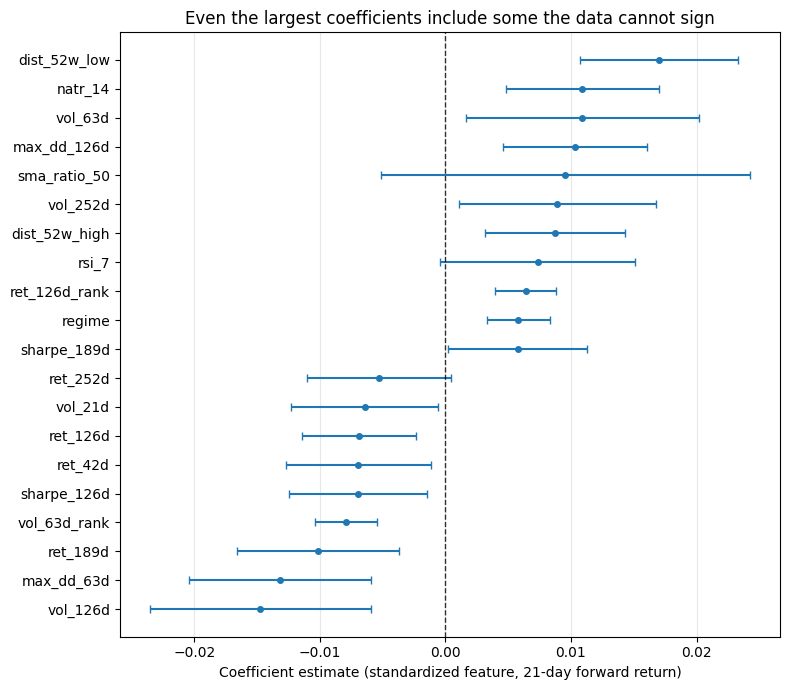

Of the 20 largest coefficients, 3 have a two-way clustered interval that includes zero.


In [17]:
TOP_COEFS = 20
CONF_Z = 1.96  # two-sided 5% normal critical value

coef_plot = (
    se_comparison.with_columns(abs_coef=pl.col("coef").abs())
    .sort("abs_coef", descending=True)
    .head(TOP_COEFS)
    .sort("coef")
)

y_pos = np.arange(coef_plot.height)
coef_values = coef_plot["coef"].to_numpy()
cluster_se = coef_plot["se_cluster"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 7))
ax.errorbar(
    x=coef_values,
    y=y_pos,
    xerr=CONF_Z * cluster_se,
    fmt="o",
    capsize=3,
    linewidth=1.5,
    markersize=4,
)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_plot["feature"].to_list())
ax.set_xlabel("Coefficient estimate (standardized feature, 21-day forward return)")
ax.set_title("Even the largest coefficients include some the data cannot sign")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

n_crosses_zero = int((np.abs(coef_values) <= CONF_Z * cluster_se).sum())
print(
    f"Of the {TOP_COEFS} largest coefficients, {n_crosses_zero} have a two-way "
    f"clustered interval that includes zero."
)

Robust standard errors are typically *larger* than OLS standard errors, making
fewer features appear significant. This is the correct adjustment: OLS was
overstating precision by ignoring the correlation structure in the errors.

The econometric toolkit offers further specialized corrections:

- **WLS** (Weighted Least Squares): explicitly models heteroscedasticity when
  the variance function is known or estimable
- **GLS/FGLS** (Generalized / Feasible GLS): corrects for both heteroscedasticity
  and autocorrelation by transforming the model
- **HAC (Newey-West)**: the standard correction for autocorrelation in a single
  time series, and the right tool once the panel is collapsed to one series per
  date — which is exactly what the IC calculation in the next section does
- **Driscoll-Kraay**: an alternative to the two-way clustering used above that
  imposes a decaying lag structure on the serial dependence rather than leaving
  it unrestricted, which buys precision when the number of symbols is small

These are valuable tools for the data modeling culture — but they fix *inference*
quality, not *prediction* quality. A coefficient with correct standard errors
still tells you about in-sample relationships, not out-of-sample forecasting power.

## Section 4: Why This Doesn't Help Prediction

We now compute the one metric that matters for trading: the out-of-sample
Information Coefficient (IC). Because trading decisions rank assets at each
decision date, IC is computed cross-sectionally — Spearman rank correlation
between predicted and realized returns *within* each date — and then summarized
across the validation period via mean, IR ($\bar{IC} / \sigma_{IC}$), and a
t-statistic on the IC time series.

That t-statistic needs the same care Section 2 demanded. Each date's IC is
measured against a 21-day forward return, so consecutive daily ICs share 20 of
21 days of outcome window and the series is autocorrelated by construction.
Dividing by $\sigma_{IC} / \sqrt{n}$ treats the dates as independent and
overstates significance by roughly the square root of the overlap. We report
the HAC-corrected statistic with the lag set to the label horizon, and the
naive one beside it to show the size of the error.

In [18]:
X_val_c = sm.add_constant(X_val_df, has_constant="add")
y_pred_val = np.asarray(ols_model.predict(X_val_c))

val_meta = df.filter(val_mask).select(["timestamp", ASSET_COL])
pred_df = val_meta.with_columns(prediction=pl.Series(y_pred_val))
ret_df = val_meta.with_columns(forward_return=pl.Series(y_val))

ic_per_date = cross_sectional_ic_series(
    pred_df,
    ret_df,
    pred_col="prediction",
    ret_col="forward_return",
    date_col="timestamp",
    entity_col=ASSET_COL,
)
# The HAC autocovariance is computed on the row order, so the series must be
# sorted by date before it is passed on.
ic_clean = ic_per_date.drop_nulls("ic").sort("timestamp")
ic_mean = float(ic_clean["ic"].mean())
ic_std = float(ic_clean["ic"].std())
n_periods = ic_clean.height
ic_ir = ic_mean / ic_std if ic_std > 0 else float("nan")

LABEL_HORIZON_DAYS = 21
ic_stats = compute_ic_hac_stats(ic_clean, ic_col="ic", label_horizon=LABEL_HORIZON_DAYS)

r2_train = ols_model.rsquared
r2_val = 1 - np.sum((y_val - y_pred_val) ** 2) / np.sum((y_val - y_val.mean()) ** 2)

print(f"In-sample R²:            {r2_train:.4f}")
print(f"Out-of-sample R²:        {r2_val:.4f}")
print(f"Out-of-sample IC mean:   {ic_mean:.4f}")
print(f"Out-of-sample IC IR:     {ic_ir:.2f}")
print(f"IC t-stat, HAC:          {ic_stats['t_stat']:.2f}  (p = {ic_stats['p_value']:.3f},")
print(f"                          {ic_stats['effective_lags']} lags, n={n_periods} dates)")
print(f"IC t-stat, naive:        {ic_stats['naive_t_stat']:.2f}  (treats dates as independent)")
print(f"Significant features:    {n_sig_cluster} (two-way clustered)")

In-sample R²:            0.0854
Out-of-sample R²:        -0.1329
Out-of-sample IC mean:   -0.0084
Out-of-sample IC IR:     -0.04
IC t-stat, HAC:          -0.22  (p = 0.830,
                          20 lags, n=231 dates)
IC t-stat, naive:        -0.60  (treats dates as independent)
Significant features:    21 (two-way clustered)


### Validation Predictions and Residuals

The left panel compares predicted vs realized returns; the right panel shows
residuals against predictions. We sample for readability on large validation sets.

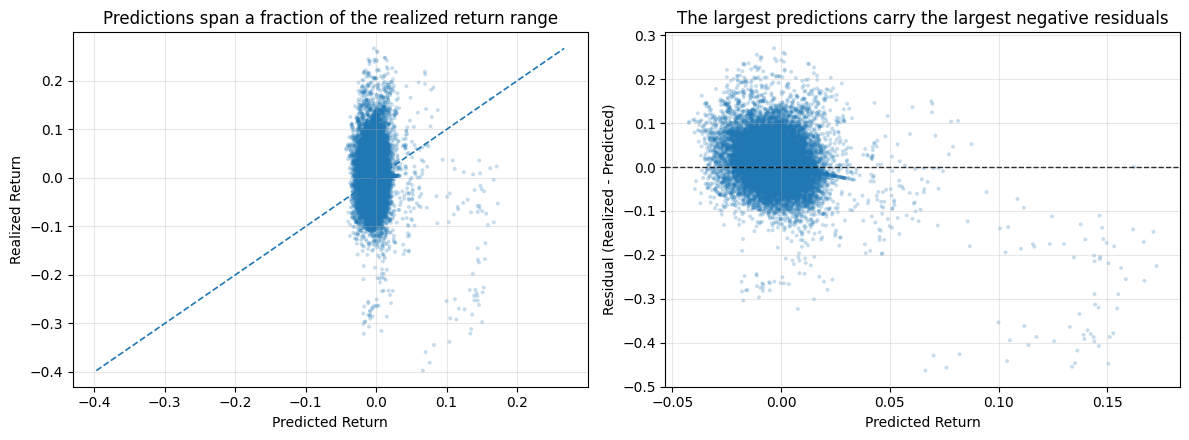

In [19]:
MAX_PLOT_POINTS = 20000
if len(y_val) > MAX_PLOT_POINTS:
    idx = np.random.default_rng(44).choice(len(y_val), size=MAX_PLOT_POINTS, replace=False)
    y_val_plot = y_val[idx]
    y_pred_plot = y_pred_val[idx]
else:
    y_val_plot = y_val
    y_pred_plot = y_pred_val

residuals_plot = y_val_plot - y_pred_plot

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_pred_plot, y_val_plot, s=8, alpha=0.25, edgecolor="none")
diag_min = min(y_pred_plot.min(), y_val_plot.min())
diag_max = max(y_pred_plot.max(), y_val_plot.max())
axes[0].plot([diag_min, diag_max], [diag_min, diag_max], linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Predicted Return")
axes[0].set_ylabel("Realized Return")
axes[0].set_title("Predictions span a fraction of the realized return range")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_pred_plot, residuals_plot, s=8, alpha=0.25, edgecolor="none")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.8)
axes[1].set_xlabel("Predicted Return")
axes[1].set_ylabel("Residual (Realized - Predicted)")
axes[1].set_title("The largest predictions carry the largest negative residuals")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Why out-of-sample $R^2$ can go negative

Both in-sample and out-of-sample $R^2$ use the same formula:

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}
      = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

The denominator $SS_{\text{tot}}$ measures total variance around the mean; the
numerator $SS_{\text{res}}$ measures residual variance after the model's
predictions. When $R^2 = 0$, the model is no better than predicting $\bar{y}$
for every observation.

**In-sample**, OLS with an intercept guarantees $R^2 \geq 0$. The intercept
ensures that the predicted mean equals the observed mean
($\bar{\hat{y}} = \bar{y}$), so the model can always do at least as well as
the constant-mean baseline. The fitted coefficients minimize $SS_{\text{res}}$
by construction.

**Out-of-sample**, both guarantees break. First, the coefficients were optimized
for the training set, not the validation set — they may amplify noise rather
than capture signal, making $SS_{\text{res}} > SS_{\text{tot}}$ and driving
$R^2$ below zero. Second, the intercept was calibrated to the training-period
mean return. If the validation period has a different mean (as it usually does
with non-stationary financial data), predictions are systematically shifted to
the wrong level. This level error inflates $SS_{\text{res}}$ even if the model
ranks returns correctly.

The out-of-sample $R^2$ printed above is negative: the model's magnitude
predictions are worse than the naive mean, driven by overfitting 52
coefficients and a stale intercept.

The IC answers a different question, and the two can disagree. IC (Spearman
rank correlation) is invariant to level shifts and scaling, so a model whose
magnitudes are badly calibrated can still rank correctly — which is why it,
not $R^2$, is the standard metric for cross-sectional return prediction in
quantitative finance. Read the IC against its HAC p-value rather than its
sign: this is one validation fold of one case study, and the naive statistic
printed beside it overstates the evidence, because it counts overlapping
windows as independent observations.

None of the diagnostic tests — Breusch-Pagan, residual autocorrelation,
Jarque-Bera, VIF — measure out-of-sample ranking accuracy. A coefficient can be
statistically significant yet contribute nothing to prediction (large sample,
tiny effect), and vice versa. The diagnostics tell us whether our *inference*
about parameter values is reliable; they say nothing about whether those
parameters produce useful *forecasts*.

This is the core insight of Section 11.1: the inferential toolkit and the
predictive toolkit answer different questions. For algorithmic trading, the
relevant question is "does this model rank future returns accurately?" — and
the relevant tool is out-of-sample evaluation, not hypothesis testing.

Section 11.2 introduces regularization — the tool that directly targets
prediction quality by trading bias for variance.

## Key Takeaways

1. **Statsmodels provides the full inferential toolkit**: standard errors,
   t-statistics, p-values, F-tests, and a battery of diagnostic tests that
   scikit-learn intentionally omits.

2. **The ETF panel violates the spherical-errors assumption in both of its
   parts**: the error variance depends on the regressors (Breusch-Pagan
   rejects) and residuals are autocorrelated within each asset, largely
   because a 21-day forward label makes consecutive observations overlap.
   Features are also pervasively collinear (many with VIF > 10).

3. **A statistic computed on a panel measures what its row order says it
   measures.** Durbin-Watson on a date-ordered panel reports cross-sectional
   dependence under the name of serial correlation; the same ordering makes
   Newey-West lag across assets rather than across time. Regroup by asset,
   cluster on every dimension the diagnostics found dependence in, and say
   which one the number came from.

4. **Robust standard errors repair one failure only.** They fix the variance
   estimate when errors are non-spherical. They cannot rescue a model whose
   exogeneity or functional form is wrong, where the point estimates
   themselves are not consistent — and they do not improve predictions.

5. **For prediction, we need a different approach**: regularization +
   out-of-sample evaluation. The next notebook introduces Ridge, LASSO,
   and Elastic Net.

**Next**: `02_regularization_paths` introduces the prediction-oriented framework
with regularized regression and walk-forward cross-validation.